# MDR-TS v12.7
**Temporal-Station Soil Moisture Model + Shallow NN Baseline**

**Author:** Jakob Balkovec
**Affiliation:** Seattle University, Computer Science
**Project:** MDR
**Notebook Type:** Training, Evaluation, Baseline Modeling
**Last Updated:** Sat Feb 14th 2026

---

## Model Summary

- **Model Name:** MDR-TS
- **Version:** v12.7
- **Task:** Regression (Soil Moisture at 5 cm depth)
- **Target Variable:** `soil_moisture_5cm`
- **Temporal Resolution:** Daily

This notebook implements a clean baseline neural model:

1. **Shallow NN Baseline**
   A 2 to 3 layer mlp trained on the derived_new feature set with proper scaling, early stopping, and full evaluation.

Later notebooks may extend this with physics-residual correction and rain-focused modeling, but this notebook must remain a baseline.

---

## Reproducibility

- **Random Seed:** 42
- **Split Directory:** `data/splits/derived_3.0/`
- **Environment:** MacBook M2 Pro (local kernel)

---

## What’s New

- Adding a layer of physics to better model the wet regime


## 1. Imports + Environment Setup

In [193]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"using device: {device}")


using device: cpu


## 2. Features

In [194]:
split_dir = Path("/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_3.0")
train_path = split_dir / "train.csv"
val_path = split_dir / "val.csv"
test_path = split_dir / "test.csv"
meta_path = split_dir / "split_meta.json"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"missing split file: {p}")

if meta_path.exists():
    print(f"found optional metadata: {meta_path}")
else:
    print("optional split_meta.json not found; continuing without it")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "soil_moisture_5cm"
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if target_col not in df.columns:
        raise ValueError(f"{target_col} missing in {name} split")

train_df = train_df.dropna(subset=[target_col]).copy()
val_df = val_df.dropna(subset=[target_col]).copy()
test_df = test_df.dropna(subset=[target_col]).copy()

# drop obvious index junk
for df in [train_df, val_df, test_df]:
    junk = [c for c in df.columns if c.lower().startswith("unnamed")]
    if junk:
        df.drop(columns=junk, inplace=True)

# autoregressive state injection: lagged soil moisture per station over time
if "station_id" not in train_df.columns:
    raise ValueError("station_id missing; needed for autoregressive lags")

if "date" in train_df.columns:
    time_col = "date"
elif "timestamp" in train_df.columns:
    time_col = "timestamp"
else:
    raise ValueError("date or timestamp missing; needed for autoregressive lags")

for df, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    df["split"] = name

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

full_df[time_col] = pd.to_datetime(full_df[time_col], errors="coerce")
if full_df[time_col].isna().any():
    bad_n = int(full_df[time_col].isna().sum())
    raise ValueError(f"{time_col} has {bad_n} unparsable values; cannot build lags safely")

full_df = full_df.sort_values(["station_id", time_col]).reset_index(drop=True)

lag_steps = [1, 2, 7]
for k in lag_steps:
    full_df[f"{target_col}_lag{k}"] = full_df.groupby("station_id")[target_col].shift(k)

# split back
train_df = full_df[full_df["split"] == "train"].copy()
val_df = full_df[full_df["split"] == "val"].copy()
test_df = full_df[full_df["split"] == "test"].copy()

state_col = f"{target_col}_lag1"
before = (len(train_df), len(val_df), len(test_df))
train_df = train_df.dropna(subset=[state_col]).copy()
val_df = val_df.dropna(subset=[state_col]).copy()
test_df = test_df.dropna(subset=[state_col]).copy()
after = (len(train_df), len(val_df), len(test_df))

print(f"added autoregressive lags: {[f'{target_col}_lag{k}' for k in lag_steps]}")
print(f"dropped lag1 nan rows | train {before[0]}->{after[0]} | val {before[1]}->{after[1]} | test {before[2]}->{after[2]}")

exclude_cols = {
    target_col, "split", "fold", "station_id", "date", "timestamp", "path", "id"
}

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

if not feature_cols:
    raise ValueError("no numeric feature columns were inferred")

# hard enforce shared feature set across splits
shared = set(feature_cols) & set(val_df.columns) & set(test_df.columns)
dropped = [c for c in feature_cols if c not in shared]
feature_cols = sorted(list(shared))

if not feature_cols:
    raise ValueError("no shared feature columns across train/val/test")

if dropped:
    print(f"dropped {len(dropped)} train-only numeric feature cols (not in all splits)")

# coerce to numeric, handle inf, compute medians on train only
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

train_medians = train_df[feature_cols].median()
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].fillna(train_medians)

print(f"train rows: {len(train_df):,} | val rows: {len(val_df):,} | test rows: {len(test_df):,}")
print(f"features: {len(feature_cols)} | state_col: {state_col}")

optional split_meta.json not found; continuing without it
added autoregressive lags: ['soil_moisture_5cm_lag1', 'soil_moisture_5cm_lag2', 'soil_moisture_5cm_lag7']
dropped lag1 nan rows | train 16972->16967 | val 2919->2919 | test 2829->2829
train rows: 16,967 | val rows: 2,919 | test rows: 2,829
features: 356 | state_col: soil_moisture_5cm_lag1


In [195]:
state_col = f"{target_col}_lag1"
if state_col not in feature_cols and state_col not in train_df.columns:
    raise ValueError(f"missing required state col: {state_col}")

def is_rain_feature(c: str) -> bool:
    s = c.lower()
    return ("rain" in s) or ("api" in s) or ("precip" in s) or ("ppt" in s)

rain_cols = [c for c in feature_cols if is_rain_feature(c)]
soil_cols = [c for c in feature_cols if c not in rain_cols]

lag_cols = [c for c in feature_cols if c.startswith(f"{target_col}_lag")]
for c in lag_cols:
    if c in rain_cols:
        rain_cols.remove(c)
    if c not in soil_cols:
        soil_cols.append(c)

if state_col in soil_cols:
    soil_cols.remove(state_col)
if state_col in rain_cols:
    rain_cols.remove(state_col)

soil_cols = sorted(list(set(soil_cols)))
rain_cols = sorted(list(set(rain_cols)))

if len(rain_cols) == 0:
    print("warning: no rain-like columns found...rain branch is gonna be weak")

print(f"rain features: {len(rain_cols)} | soil features: {len(soil_cols)} | state: {state_col}")
print(f"lag features total: {len(lag_cols)} (excluding state lag1 from inputs)")

rain features: 43 | soil features: 312 | state: soil_moisture_5cm_lag1
lag features total: 3 (excluding state lag1 from inputs)


## 3. Masking

In [196]:
gate_col = None
for c in ["G_rain_sum_7d", "G_API", "G_rain_sum_3d"]:
    if c in train_df.columns:
        gate_col = c
        break

wet_masks = None
wet_threshold = None

if gate_col is None:
    print("wet/dry reporting skipped: no gate column found")
else:
    # ensure numeric + handle inf
    for df in [train_df, val_df, test_df]:
        df[gate_col] = pd.to_numeric(df[gate_col], errors="coerce")
        df[gate_col] = df[gate_col].replace([np.inf, -np.inf], np.nan)

    if train_df[gate_col].isna().all():
        print(f"wet/dry skipped: {gate_col} is entirely NaN in train")
    else:
        wet_threshold = float(train_df[gate_col].quantile(0.90))

        wet_masks = {
            "train": (train_df[gate_col].to_numpy() >= wet_threshold),
            "val": (val_df[gate_col].to_numpy() >= wet_threshold),
            "test": (test_df[gate_col].to_numpy() >= wet_threshold),
        }

        print(f"wet/dry gate column: {gate_col}")
        print(f"wet threshold (train q0.90): {wet_threshold:.6f}")

wet/dry gate column: G_rain_sum_7d
wet threshold (train q0.90): 92.540000


## 4. Scaling + Data Loaders

In [197]:
X_soil_train = train_df[soil_cols].to_numpy(dtype=np.float32)
X_soil_val = val_df[soil_cols].to_numpy(dtype=np.float32)
X_soil_test = test_df[soil_cols].to_numpy(dtype=np.float32)

if len(rain_cols) > 0:
    X_rain_train = train_df[rain_cols].to_numpy(dtype=np.float32)
    X_rain_val = val_df[rain_cols].to_numpy(dtype=np.float32)
    X_rain_test = test_df[rain_cols].to_numpy(dtype=np.float32)
else:
    X_rain_train = np.zeros((len(train_df), 1), dtype=np.float32)
    X_rain_val = np.zeros((len(val_df), 1), dtype=np.float32)
    X_rain_test = np.zeros((len(test_df), 1), dtype=np.float32)

m_prev_train = train_df[state_col].to_numpy(dtype=np.float32).reshape(-1, 1)
m_prev_val = val_df[state_col].to_numpy(dtype=np.float32).reshape(-1, 1)
m_prev_test = test_df[state_col].to_numpy(dtype=np.float32).reshape(-1, 1)

y_train = train_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

for name, arr in [
    ("soil_train", X_soil_train), ("soil_val", X_soil_val), ("soil_test", X_soil_test),
    ("rain_train", X_rain_train), ("rain_val", X_rain_val), ("rain_test", X_rain_test),
    ("m_prev_train", m_prev_train), ("m_prev_val", m_prev_val), ("m_prev_test", m_prev_test),
    ("y_train", y_train), ("y_val", y_val), ("y_test", y_test),
]:
    if not np.isfinite(arr).all():
        raise ValueError(f"non-finite values found in {name}")

In [198]:
soil_scaler = StandardScaler()
X_soil_train_s = soil_scaler.fit_transform(X_soil_train).astype(np.float32)
X_soil_val_s = soil_scaler.transform(X_soil_val).astype(np.float32)
X_soil_test_s = soil_scaler.transform(X_soil_test).astype(np.float32)

rain_scaler = StandardScaler()
X_rain_train_s = rain_scaler.fit_transform(X_rain_train).astype(np.float32)
X_rain_val_s = rain_scaler.transform(X_rain_val).astype(np.float32)
X_rain_test_s = rain_scaler.transform(X_rain_test).astype(np.float32)

X_soil_train_t = torch.from_numpy(X_soil_train_s)
X_soil_val_t = torch.from_numpy(X_soil_val_s)
X_soil_test_t = torch.from_numpy(X_soil_test_s)

X_rain_train_t = torch.from_numpy(X_rain_train_s)
X_rain_val_t = torch.from_numpy(X_rain_val_s)
X_rain_test_t = torch.from_numpy(X_rain_test_s)

m_prev_train_t = torch.from_numpy(m_prev_train.astype(np.float32))
m_prev_val_t = torch.from_numpy(m_prev_val.astype(np.float32))
m_prev_test_t = torch.from_numpy(m_prev_test.astype(np.float32))

y_train_t = torch.from_numpy(y_train.astype(np.float32))
y_val_t = torch.from_numpy(y_val.astype(np.float32))
y_test_t = torch.from_numpy(y_test.astype(np.float32))

In [199]:

train_ds = TensorDataset(X_soil_train_t, X_rain_train_t, m_prev_train_t, y_train_t)
val_ds = TensorDataset(X_soil_val_t, X_rain_val_t, m_prev_val_t, y_val_t)
test_ds = TensorDataset(X_soil_test_t, X_rain_test_t, m_prev_test_t, y_test_t)

batch_size = 1024 if len(train_ds) >= 50000 else 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"batch size: {batch_size}")
print(f"soil dims: {X_soil_train_t.shape[1]} | rain dims: {X_rain_train_t.shape[1]} | state dims: 1")
print(f"train/val/test: {len(train_ds):,}/{len(val_ds):,}/{len(test_ds):,}")

batch size: 512
soil dims: 312 | rain dims: 43 | state dims: 1
train/val/test: 16,967/2,919/2,829


## 5. Model

In [200]:
soil_h1 = 256
soil_h2 = 128
rain_h1 = 64
rain_h2 = 32
dropout_p = 0.1
log_var_min = -10.0
log_var_max = 6.0

class WaterBalanceGaussianNLL(nn.Module):
    def __init__(self, soil_dim: int, rain_dim: int):
        super().__init__()

        self.soil_net = nn.Sequential(
            nn.Linear(soil_dim, soil_h1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(soil_h1, soil_h2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        self.rain_net = nn.Sequential(
            nn.Linear(rain_dim, rain_h1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(rain_h1, rain_h2),
            nn.ReLU(),
        )

        # infiltration flux from rain, nonnegative then saturating
        self.head_infil = nn.Linear(rain_h2, 1)

        # drainage flux from soil features + current state, nonnegative
        self.head_drain = nn.Linear(soil_h2 + 1, 1)

        # uncertainty head
        self.head_log_var = nn.Linear(soil_h2 + rain_h2 + 1, 1)

        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x_soil, x_rain, m_prev):
        h_soil = self.soil_net(x_soil)
        h_rain = self.rain_net(x_rain)

        infil_raw = self.head_infil(h_rain)
        infil_pos = torch.nn.functional.softplus(infil_raw)
        infil = 1.0 - torch.exp(-infil_pos)

        drain_in = torch.cat([h_soil, m_prev], dim=1)
        drain_raw = self.head_drain(drain_in)
        drain = torch.nn.functional.softplus(drain_raw)

        mu = m_prev + (infil - drain)
        mu = torch.clamp(mu, min=0.0, max=1.0)

        lv_in = torch.cat([h_soil, h_rain, m_prev], dim=1)
        log_var = self.head_log_var(lv_in)
        log_var = torch.clamp(log_var, min=log_var_min, max=log_var_max)

        return mu, log_var, infil, drain

model = WaterBalanceGaussianNLL(
    soil_dim=X_soil_train_t.shape[1],
    rain_dim=X_rain_train_t.shape[1],
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

WaterBalanceGaussianNLL(
  (soil_net): Sequential(
    (0): Linear(in_features=312, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (rain_net): Sequential(
    (0): Linear(in_features=43, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (head_infil): Linear(in_features=32, out_features=1, bias=True)
  (head_drain): Linear(in_features=129, out_features=1, bias=True)
  (head_log_var): Linear(in_features=161, out_features=1, bias=True)
)


## 6. Training Loop + Early Stopping

In [201]:
def safe_r2(y_true, y_pred):
    if y_true.size == 0:
        return np.nan
    if np.allclose(y_true, y_true[0]):
        return np.nan
    return float(r2_score(y_true, y_pred))

In [202]:
def gaussian_nll(mu, log_var, target):
    err2 = (target - mu) ** 2
    inv_var = torch.exp(-log_var)
    return torch.mean(0.5 * (inv_var * err2 + log_var))

In [203]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    y_true_chunks = []
    y_pred_chunks = []

    for x_soil, x_rain, m_prev, yb in loader:
        x_soil = x_soil.to(device)
        x_rain = x_rain.to(device)
        m_prev = m_prev.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            mu, log_var, infil, drain = model(x_soil, x_rain, m_prev)
            loss = gaussian_nll(mu, log_var, yb)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        y_true_chunks.append(yb.detach().cpu().numpy().reshape(-1))
        y_pred_chunks.append(mu.detach().cpu().numpy().reshape(-1))

    y_true_epoch = np.concatenate(y_true_chunks)
    y_pred_epoch = np.concatenate(y_pred_chunks)
    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, y_true_epoch, y_pred_epoch

In [204]:
max_epochs = 200
patience = 15
wait = 0
best_val_r2 = -np.inf
best_state = None

epoch_bar = tqdm(range(1, max_epochs + 1), desc="training", leave=True)

for epoch in epoch_bar:
    train_loss, _, _ = run_epoch(train_loader, training=True)
    val_loss, y_val_true_epoch, y_val_pred_epoch = run_epoch(val_loader, training=False)

    val_r2 = safe_r2(y_val_true_epoch, y_val_pred_epoch)
    val_mae = float(mean_absolute_error(y_val_true_epoch, y_val_pred_epoch))
    val_rmse = float(np.sqrt(mean_squared_error(y_val_true_epoch, y_val_pred_epoch)))

    improved = np.isnan(best_val_r2) or (
        not np.isnan(val_r2) and (val_r2 > best_val_r2 + 1e-6)
    )

    if improved:
        best_val_r2 = val_r2
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    epoch_bar.set_postfix(
        train_loss=f"{train_loss:.4f}",
        val_loss=f"{val_loss:.4f}",
        val_r2=f"{val_r2:.4f}",
        wait=wait,
    )

    if wait >= patience:
        print(f"early stopping at epoch {epoch}; best val_r2={best_val_r2:.6f}")
        break

if best_state is None:
    raise RuntimeError("training did not produce a valid checkpoint")

model.load_state_dict(best_state)
model.to(device)
print(f"restored best model with val_r2={best_val_r2:.6f}")

training:   0%|          | 0/200 [00:00<?, ?it/s]

early stopping at epoch 24; best val_r2=0.974460
restored best model with val_r2=0.974460


## 7. Evaluation

In [205]:
@torch.no_grad()
def predict_scaled(
    X_soil_scaled: np.ndarray,
    X_rain_scaled: np.ndarray,
    m_prev: np.ndarray,
    batch_size: int = 4096,
):
    model.eval()

    soil_t = torch.from_numpy(X_soil_scaled.astype(np.float32))
    rain_t = torch.from_numpy(X_rain_scaled.astype(np.float32))
    mprev_t = torch.from_numpy(m_prev.astype(np.float32)).reshape(-1, 1)

    loader = DataLoader(
        TensorDataset(soil_t, rain_t, mprev_t),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    preds = []

    for xs, xr, mp in loader:
        xs = xs.to(device)
        xr = xr.to(device)
        mp = mp.to(device)

        mu, log_var, infil, drain = model(xs, xr, mp)
        preds.append(mu.detach().cpu().numpy().reshape(-1))

    return np.concatenate(preds)

In [206]:
@torch.no_grad()
def predict_fluxes_scaled(
    X_soil_scaled: np.ndarray,
    X_rain_scaled: np.ndarray,
    m_prev: np.ndarray,
    batch_size: int = 4096,
):
    model.eval()

    soil_t = torch.from_numpy(X_soil_scaled.astype(np.float32))
    rain_t = torch.from_numpy(X_rain_scaled.astype(np.float32))
    mprev_t = torch.from_numpy(m_prev.astype(np.float32)).reshape(-1, 1)

    loader = DataLoader(
        TensorDataset(soil_t, rain_t, mprev_t),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    infil_list = []
    drain_list = []

    for xs, xr, mp in loader:
        xs = xs.to(device)
        xr = xr.to(device)
        mp = mp.to(device)

        mu, log_var, infil, drain = model(xs, xr, mp)
        infil_list.append(infil.detach().cpu().numpy().reshape(-1))
        drain_list.append(drain.detach().cpu().numpy().reshape(-1))

    return np.concatenate(infil_list), np.concatenate(drain_list)

In [207]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.size == 0:
        return {"r2": np.nan, "mae": np.nan, "rmse": np.nan, "bias": np.nan, "medae": np.nan, "pearson": np.nan}

    r2 = safe_r2(y_true, y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    err = y_pred - y_true
    bias = float(np.mean(err))
    medae = float(np.median(np.abs(err)))

    y_true_c = y_true - np.mean(y_true)
    y_pred_c = y_pred - np.mean(y_pred)
    denom = float(np.sqrt(np.sum(y_true_c ** 2)) * np.sqrt(np.sum(y_pred_c ** 2)))
    pearson = float(np.sum(y_true_c * y_pred_c) / denom) if denom > 0 else np.nan

    return {"r2": r2, "mae": mae, "rmse": rmse, "bias": bias, "medae": medae, "pearson": pearson}

In [208]:
y_train_pred = predict_scaled(X_soil_train_s, X_rain_train_s, m_prev_train)
y_val_pred = predict_scaled(X_soil_val_s, X_rain_val_s, m_prev_val)
y_test_pred = predict_scaled(X_soil_test_s, X_rain_test_s, m_prev_test)

y_train_true = y_train.reshape(-1)
y_val_true = y_val.reshape(-1)
y_test_true = y_test.reshape(-1)

metrics = {
    "train": {"overall": compute_metrics(y_train_true, y_train_pred)},
    "val": {"overall": compute_metrics(y_val_true, y_val_pred)},
    "test": {"overall": compute_metrics(y_test_true, y_test_pred)},
}

if wet_masks is not None:
    for split_name, y_true_split, y_pred_split in [
        ("train", y_train_true, y_train_pred),
        ("val", y_val_true, y_val_pred),
        ("test", y_test_true, y_test_pred),
    ]:
        mask_wet = wet_masks[split_name]
        mask_dry = ~mask_wet
        metrics[split_name]["wet"] = compute_metrics(y_true_split[mask_wet], y_pred_split[mask_wet])
        metrics[split_name]["dry"] = compute_metrics(y_true_split[mask_dry], y_pred_split[mask_dry])

In [209]:
test_abs_err = np.abs(y_test_true - y_test_pred)
k = max(1, int(np.ceil(0.10 * len(test_abs_err))))
worst_idx = np.argsort(test_abs_err)[-k:]
metrics["test"]["worst_decile"] = compute_metrics(y_test_true[worst_idx], y_test_pred[worst_idx])

rows = []
for split_name in ["train", "val", "test"]:
    for subset_name in ["overall", "wet", "dry", "worst_decile"]:
        if subset_name in metrics[split_name]:
            m = metrics[split_name][subset_name]
            rows.append(
                {
                    "split": split_name,
                    "subset": subset_name,
                    "r2": m["r2"],
                    "mae": m["mae"],
                    "rmse": m["rmse"],
                    "bias": m["bias"],
                    "medae": m["medae"],
                    "pearson": m["pearson"],
                }
            )

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

split       subset       r2      mae     rmse      bias    medae  pearson
train      overall 0.968748 0.009564 0.018075 -0.000988 0.004539 0.984416
train          wet 0.884497 0.015885 0.020098 -0.000114 0.013167 0.942861
train          dry 0.970053 0.008862 0.017836 -0.001085 0.003998 0.985062
  val      overall 0.974460 0.009161 0.016096 -0.001143 0.004852 0.987286
  val          wet 0.742420 0.016061 0.021170 -0.000716 0.012376 0.872007
  val          dry 0.978077 0.008184 0.015242 -0.001203 0.004024 0.989093
 test      overall 0.971928 0.008695 0.015670 -0.001112 0.004189 0.986009
 test          wet 0.572281 0.014523 0.019231 -0.001462 0.011646 0.794453
 test          dry 0.973953 0.007906 0.015125 -0.001064 0.003795 0.987016
 test worst_decile 0.459196 0.039040 0.044350 -0.024249 0.031706 0.848158


In [210]:
artifact_dir = Path("/Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.7/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pred_parts = []
for split_name, y_true_split, y_pred_split in [
    ("train", y_train_true, y_train_pred),
    ("val", y_val_true, y_val_pred),
    ("test", y_test_true, y_test_pred),
]:
    data = {
        "split": split_name,
        "y_true": y_true_split,
        "y_pred": y_pred_split,
        "abs_err": np.abs(y_true_split - y_pred_split),
    }
    if wet_masks is not None:
        data["is_wet"] = wet_masks[split_name].astype(int)
    pred_parts.append(pd.DataFrame(data))

preds_df = pd.concat(pred_parts, ignore_index=True)
preds_path = artifact_dir / "preds_mlp_v12_7.csv"
metrics_path = artifact_dir / "metrics_mlp_v12_7.json"

preds_df.to_csv(preds_path, index=False)
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved predictions: {preds_path}")
print(f"saved metrics: {metrics_path}")

saved predictions: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.7/artifacts/preds_mlp_v12_7.csv
saved metrics: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.7/artifacts/metrics_mlp_v12_7.json


## 8. Plots

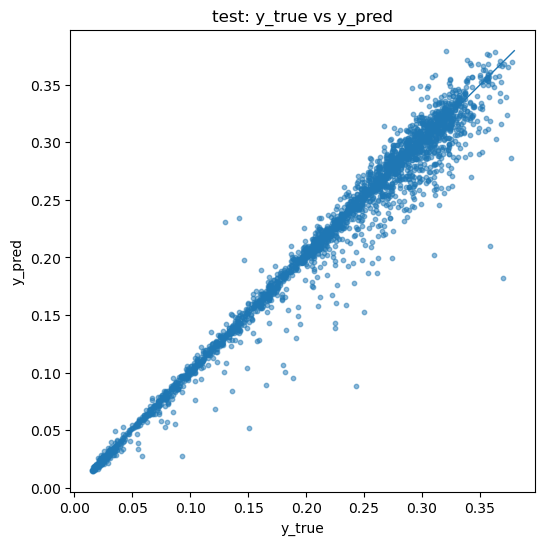

In [211]:
residuals_test = y_test_true - y_test_pred
abs_err_test = np.abs(residuals_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_true, y_test_pred, s=10, alpha=0.5)
min_v = float(min(y_test_true.min(), y_test_pred.min()))
max_v = float(max(y_test_true.max(), y_test_pred.max()))
ax.plot([min_v, max_v], [min_v, max_v], linewidth=1)
ax.set_xlabel("y_true")
ax.set_ylabel("y_pred")
ax.set_title("test: y_true vs y_pred")
plt.show()

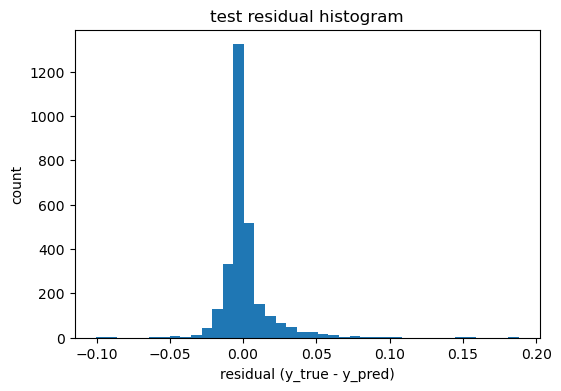

In [212]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals_test, bins=40)
ax.set_xlabel("residual (y_true - y_pred)")
ax.set_ylabel("count")
ax.set_title("test residual histogram")
plt.show()

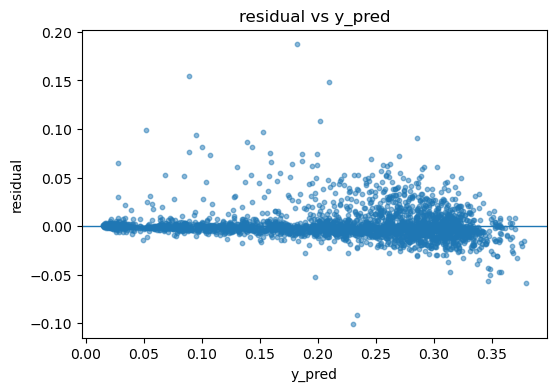

In [213]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred, residuals_test, s=10, alpha=0.5)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("y_pred")
ax.set_ylabel("residual")
ax.set_title("residual vs y_pred")
plt.show()

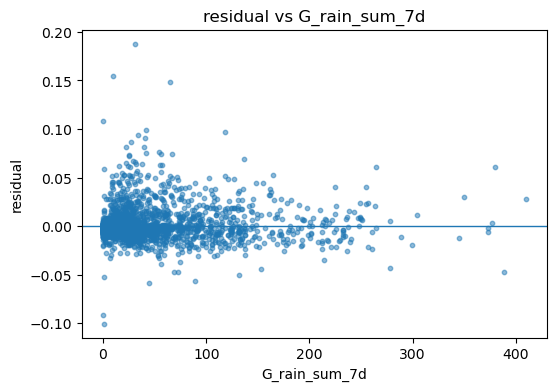

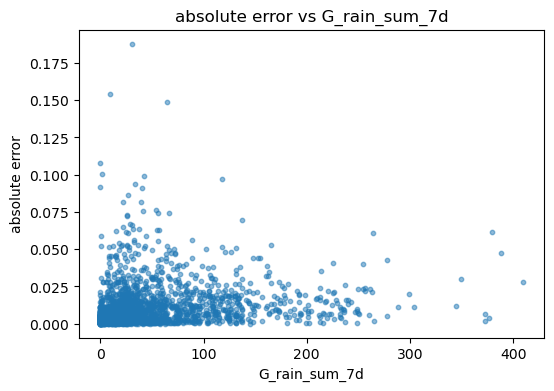

In [214]:
if gate_col is not None:
    gate_test = test_df[gate_col].to_numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, residuals_test, s=10, alpha=0.5)
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("residual")
    ax.set_title(f"residual vs {gate_col}")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, abs_err_test, s=10, alpha=0.5)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("absolute error")
    ax.set_title(f"absolute error vs {gate_col}")
    plt.show()

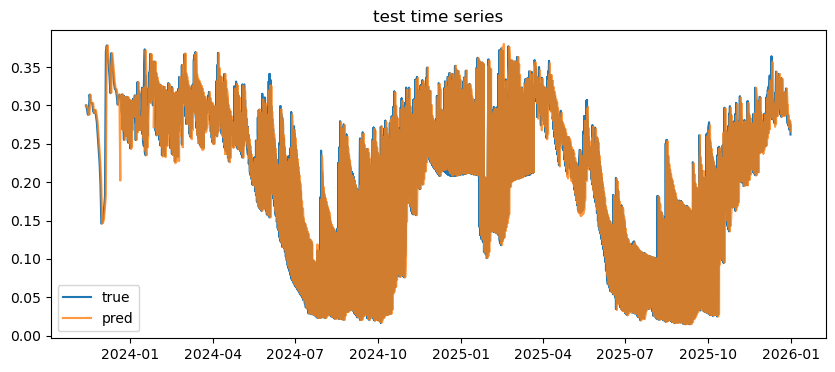

In [215]:
dates = pd.to_datetime(test_df["date"])
order = np.argsort(dates)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates.iloc[order], y_test_true[order], label="true")
ax.plot(dates.iloc[order], y_test_pred[order], label="pred", alpha=0.8)
ax.set_title("test time series")
ax.legend()
plt.show()

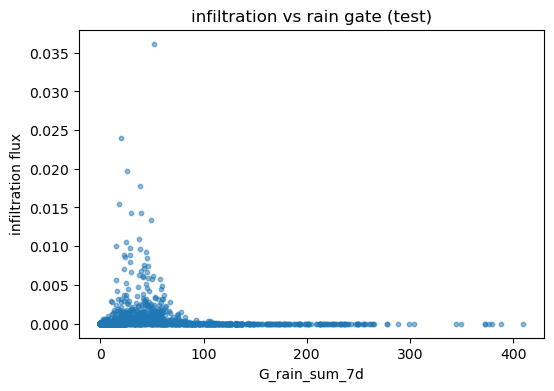

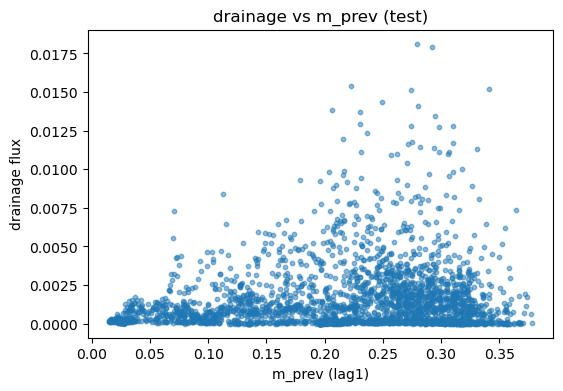

In [216]:
infil_test, drain_test = predict_fluxes_scaled(X_soil_test_s, X_rain_test_s, m_prev_test)

if gate_col is not None:
    gate_test = test_df[gate_col].to_numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, infil_test, s=10, alpha=0.5)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("infiltration flux")
    ax.set_title("infiltration vs rain gate (test)")
    plt.show()
else:
    print("gate_col not found; skipping infiltration vs gate plot")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(m_prev_test.reshape(-1), drain_test, s=10, alpha=0.5)
ax.set_xlabel("m_prev (lag1)")
ax.set_ylabel("drainage flux")
ax.set_title("drainage vs m_prev (test)")
plt.show()

## 9. Analysis

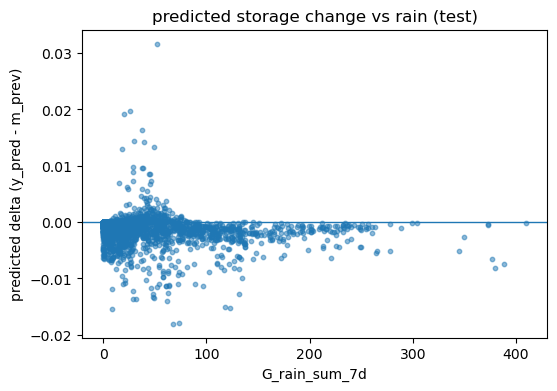

In [217]:
delta_pred_test = y_test_pred.reshape(-1) - m_prev_test.reshape(-1)

if gate_col is not None:
    rain_test = test_df[gate_col].to_numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(rain_test, delta_pred_test, s=10, alpha=0.5)
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("predicted delta (y_pred - m_prev)")
    ax.set_title("predicted storage change vs rain (test)")
    plt.show()
else:
    print("gate_col not defined; cannot plot vs rain")

In [218]:
y_test_persistence = m_prev_test.reshape(-1)

print("persistence r2:", r2_score(y_test_true, y_test_persistence))
print("persistence rmse:", np.sqrt(mean_squared_error(y_test_true, y_test_persistence)))

persistence r2: 0.9718092083930969
persistence rmse: 0.01570370065318373


In [219]:
thr = np.quantile(test_df[gate_col], 0.95)
storm_mask = test_df[gate_col].values >= thr

print("storm r2:", r2_score(y_test_true[storm_mask], y_test_pred[storm_mask]))
print("storm rmse:", np.sqrt(mean_squared_error(y_test_true[storm_mask], y_test_pred[storm_mask])))

storm r2: 0.23931419849395752
storm rmse: 0.01948181019327108


In [220]:
X_rain_shuffled = X_rain_test_s.copy()
np.random.shuffle(X_rain_shuffled)

y_pred_shuffled = predict_scaled(X_soil_test_s, X_rain_shuffled, m_prev_test)

print("r2 shuffled rain:", r2_score(y_test_true, y_pred_shuffled))

r2 shuffled rain: 0.9712346196174622


In [221]:
print("target in feature_cols:", target_col in feature_cols)

target in feature_cols: False


In [222]:
print([c for c in feature_cols if target_col in c])

['soil_moisture_5cm_lag1', 'soil_moisture_5cm_lag2', 'soil_moisture_5cm_lag7']


Found it

In [223]:
print(train_df["date"].max(), val_df["date"].min())

2021-09-23 00:00:00 2021-09-24 00:00:00
